In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [93]:
sales = pd.read_csv(
    "m5-forecasting-accuracy/sales_train_validation.csv",
    dtype={
        "item_id": "category",
        "dept_id": "category",
        "cat_id": "category",
        "store_id": "category",
        "state_id": "category"
    }
)
calendar=pd.read_csv("m5-forecasting-accuracy/calendar.csv")
sell_prices = pd.read_csv(
    "m5-forecasting-accuracy/sell_prices.csv",
    dtype={
        "store_id": "category",
        "item_id": "category"
    }
)
eval=pd.read_csv(
    "m5-forecasting-accuracy/sales_train_evaluation.csv",
    dtype={
        "item_id": "category",
        "dept_id": "category",
        "cat_id": "category",
        "store_id": "category",
        "state_id": "category"
    }
)
eval.drop([f"d_{i}" for i in range(1,1914)], axis=1, inplace=True)

In [51]:
eval.shape

(30490, 34)

In [5]:
print("--------Categories--------")
print("Categories:",*(sales["cat_id"].unique()))
print("structured:",*(sales["dept_id"].unique()))
print()
print("---------Locations---------")
print("States:",*(sales["state_id"].unique()))
print("Stores:",*(sales["store_id"].unique()))
print("Amount Stores:",len(sales["store_id"].unique()))
print()
print("---------Items---------")
print("Amount Items:",len(sales["item_id"].unique()))
print("All Items are noted for each of the 10 stores")
print(f"--> {len(sales['id'].unique())} entries total")

--------Categories--------
Categories: HOBBIES HOUSEHOLD FOODS
structured: HOBBIES_1 HOBBIES_2 HOUSEHOLD_1 HOUSEHOLD_2 FOODS_1 FOODS_2 FOODS_3

---------Locations---------
States: CA TX WI
Stores: CA_1 CA_2 CA_3 CA_4 TX_1 TX_2 TX_3 WI_1 WI_2 WI_3
Amount Stores: 10

---------Items---------
Amount Items: 3049
All Items are noted for each of the 10 stores
--> 30490 entries total


In [6]:
col=list(sales.columns)
for x in ['id','item_id','dept_id','cat_id','store_id','state_id']:
    col.remove(x)

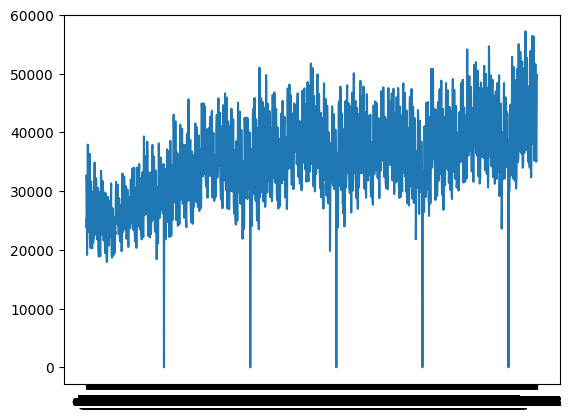

In [8]:
plt.plot(col, sales[col].sum())

In [111]:
df = sales.melt(
    id_vars=["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"],
    var_name="d",
    value_name="sales"
)
df["sales"] = df["sales"].astype("float32")

In [98]:
df = eval.melt(
    id_vars=["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"],
    var_name="d",
    value_name="sales"
)
df["sales"] = df["sales"].astype("float32")

In [112]:
df = pd.get_dummies(df, columns=["cat_id","dept_id","state_id"])
df = df.merge(calendar, on="d", how="left")
df["date"] = pd.to_datetime(df["date"])

In [113]:
df = df.merge(
    sell_prices,
    on=["store_id", "item_id", "wm_yr_wk"],
    how="left"
)
df["sell_price"] = df["sell_price"].astype("float32")
df = df.sort_values(["id", "date"]).reset_index(drop=True)

In [114]:
# DATUMSFEATURES
df["wday"]  = df["wday"].astype("int8")
df["month"] = df["date"].dt.month.astype("int8")
df["is_month_start"] = df["date"].dt.is_month_start.astype(bool)
df["is_month_end"] = df["date"].dt.is_month_end.astype(bool)
df["week_of_year"] = df["date"].dt.isocalendar().week.astype("int8")
df["quarter"] = df["date"].dt.quarter.astype("int8")

In [115]:
# LAG FEATURES
lags = [7, 14, 28, 56]
for lag in lags:
    df[f"lag_{lag}"] = (
        df.groupby("id")["sales"]
          .shift(lag)
          .astype("float32")
    )

In [116]:
# ROLLING FEATURES
df["rolling_mean_7"] = (
    df.groupby("id")["sales"]
      .shift(7)
      .rolling(7)
      .mean()
      .astype("float32")
)
df["rolling_mean_28"] = (
    df.groupby("id")["sales"]
      .shift(28)
      .rolling(28)
      .mean()
      .astype("float32")
)
df["rolling_std_28"] = (
    df.groupby("id")["sales"]
      .shift(28)
      .rolling(28)
      .std()
      .astype("float32")
)
df["rolling_mean_7_lag_28"] = (
    df.groupby("id")["sales"]
      .shift(28)
      .rolling(7)
      .mean()
      .astype("float32")
)

In [117]:
# PREIS FEATURES
df["price_rel_to_mean"] = (
    df["sell_price"] /
    df.groupby("id")["sell_price"].transform("mean")
).astype("float32")
df["price_change"] = (
    df.groupby("id")["sell_price"]
      .pct_change()
).astype("float32")

/var/folders/x8/7q22x6x94jzbhppdbldgnk300000gn/T/ipykernel_11664/2869788926.py:8: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change()


In [118]:
df = df[df["lag_28"].notna()].reset_index(drop=True)
print(df.shape)

(57473650, 46)


In [105]:
df.columns

Index(['id', 'item_id', 'store_id', 'd', 'sales', 'cat_id_HOBBIES',
       'cat_id_HOUSEHOLD', 'cat_id_FOODS', 'dept_id_HOBBIES_1',
       'dept_id_HOBBIES_2', 'dept_id_HOUSEHOLD_1', 'dept_id_HOUSEHOLD_2',
       'dept_id_FOODS_1', 'dept_id_FOODS_2', 'dept_id_FOODS_3', 'state_id_CA',
       'state_id_TX', 'state_id_WI', 'date', 'wm_yr_wk', 'weekday', 'wday',
       'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2',
       'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI', 'sell_price',
       'is_month_start', 'is_month_end', 'week_of_year', 'quarter', 'lag_7',
       'lag_14', 'lag_28', 'lag_56', 'rolling_mean_7', 'rolling_mean_28',
       'rolling_std_28', 'rolling_mean_7_lag_28', 'price_rel_to_mean',
       'price_change'],
      dtype='object')

In [119]:
keep_cols = [ # TRAIN
    "sales",
    "item_id",
    "store_id",
    'cat_id_HOBBIES','cat_id_HOUSEHOLD', 'cat_id_FOODS', 'dept_id_HOBBIES_1','dept_id_HOBBIES_2', 'dept_id_HOUSEHOLD_1', 'dept_id_HOUSEHOLD_2','dept_id_FOODS_1', 'dept_id_FOODS_2', 'dept_id_FOODS_3', 'state_id_CA','state_id_TX', 'state_id_WI',
    "date",
    "wday",
    "month",
    "year",
    "quarter",
    'week_of_year',
    #'is_month_start','is_month_end',
    'event_name_1','event_type_1',
    'snap_CA', 'snap_TX', 'snap_WI',
    "sell_price",
    "lag_7","lag_28",#"lag_14","lag_56",
    "rolling_mean_28",'rolling_std_28',#"rolling_mean_7",'rolling_mean_7_lag_28',
    'price_rel_to_mean',#'price_change'
]

In [59]:
keep_cols = [ # TEST
    "sales",
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id",
    "date",
    "wday",
    "month",
    "year",
    "quarter",
    'week_of_year',
    #'is_month_start','is_month_end',
    'event_name_1','event_type_1',
    'snap_CA', 'snap_TX', 'snap_WI',
    "sell_price",
    "lag_7",#"lag_28","lag_14","lag_56",
    "rolling_mean_7",#"rolling_mean_28",'rolling_std_28','rolling_mean_7_lag_28',
    'price_rel_to_mean',#'price_change'
]

In [120]:
df = df[keep_cols]

In [121]:
df = df.iloc[-365*2*30490:]

In [122]:
print("Memory usage (GB):",
      df.memory_usage(deep=True).sum() / 1024**3)

Memory usage (GB): 3.266836474649608


In [ ]:
df.to_csv("../m5-forecasting-accuracy/train.csv", index=False)

In [ ]:
df.to_csv("../m5-forecasting-accuracy/test.csv", index=False)